In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import statsmodels.api as sm
from scipy.stats import scoreatpercentile, percentileofscore
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score

In [3]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))

def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])

In [4]:
# old_data_dir = '/media/ssd1/huong/PCR-huong/data'
# new_data_dir = os.path.join(old_data_dir, 'new_data')
# old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
# new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

old_data_dir = '../../data/current_result_data'  #'/media/ssd1/huong/PCR-huong/data'
new_data_dir = '../../data/current_result_data'  #os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = '../../data/current_result_data'  #os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = '../../data/current_result_data' #os.path.join(new_data_dir, 'model_outputs')

In [5]:
# old_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# old_groundtruth_test_water_ids = old_groundtruth[(old_groundtruth.split == 'test') & (old_groundtruth.sample_type == 'Negative Control (qPCR)')].sample_id.unique()
# new_groundtruth_test_water_ids = groundtruth_df[(groundtruth_df.split == 'test') & (groundtruth_df.sample_type == 'Negative Control (qPCR)')].sample_id.unique()

# [i for i in old_groundtruth_test_water_ids if i in new_groundtruth_test_water_ids]

In [6]:
water_well_ids = ['S624960', 'S993281', 'S1122933', 'S897698', 
                  'S1262658', 'S1168204', 'S184660', 'S1270893']

##### read groundtruth data

In [7]:
known_df = pd.read_csv(os.path.join(old_data_dir, 'known_dilution_data.csv'))
karlen_df = pd.read_csv(os.path.join(old_data_dir, 'qpcr_karlen.csv'))
karlen_df['groundtruth_label'] = 1
karlen_df['curve_idx'] = karlen_df.curve_idx + '_' + karlen_df.data_set
karlen_df['inv_dilution_fold'] = 1/karlen_df.dilution_fold
chip60_df = pd.read_csv(os.path.join(old_data_dir, 'chipPCR_C60amp.csv'))
chip60_df['groundtruth_label'] = 1*(chip60_df.dilution != 0)


# curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
# sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
# igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

curve_df = pd.read_hdf('../../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../../data//data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../../data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))
thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'

##### read prediction data : fusion

In [8]:
## old data

# known_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_known_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_karlen_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_chip60_pred_df.csv'))

known_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_known_pred_df.csv'))
karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_karlen_pred_df.csv'))
chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_chip60_pred_df.csv'))

# known_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_known_pred.csv'))
# chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))
# test_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))


In [9]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_test_pred_df.csv'))
test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'fusion_vit_delta64_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))

test_pred = (test_pred
             .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
                    on='curve_idx')
             .merge(groundtruth_df.loc[groundtruth_df.split == 'test', 
                                       ['curve_idx','sample_id','target','igi_call','groundtruth']],
                    on='curve_idx')
             )

# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# test_pred = test_pred[test_pred.split == 'test']
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))

# test_pred = (test_pred
#              .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
#                     on='curve_idx')
#              .merge(groundtruth_df
#                     .loc[groundtruth_df.cycle_no == 40,
#                          ['curve_idx','sample_id','target','igi_call','groundtruth']],
#                     on='curve_idx')
#              )

test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

##### read prediction data : qpcR

In [10]:
chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))
known_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_known_pred.csv'))
karlen_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_karlen.csv'))

# karlen_qpcr_pred = pd.DataFrame()
# for i in range(1,4):
#     df = pd.read_csv(os.path.join(old_modeloutput_dir, f'qpcr_karlen{i}_pred.csv'))
#     df['curve_idx'] = df['curve_idx'] + f'_karlen{i}'
#     karlen_qpcr_pred = pd.concat([karlen_qpcr_pred, df])
# karlen_qpcr_pred = karlen_qpcr_pred.reset_index()


In [11]:
qpcr_known_test = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
qpcr_known_water = (qpcr_known_test[qpcr_known_test.split == 'test']
                   .merge(join_df.loc[(join_df.cycle_no == 1) & (join_df.sample_id.isin(water_well_ids)), ['curve_idx']],
                          on='curve_idx'))
qpcr_known_water['dilution_level'] = 0
qpcr_known_pred_df = pd.concat([(known_qpcr_pred
                      .merge(known_df.loc[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP'), ['curve_idx','dilution_level']], 
                             on='curve_idx')),
                                qpcr_known_water[['curve_idx','eff','groundtruth_label','prob','dilution_level']]])



##### read prediction data : qPCRdeepNet

In [12]:
chip60_deep_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'rn_test_chip60_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
chip60_deep_pred = (chip60_deep_pred
                    .merge(chip60_df.loc[chip60_df['Index'] == 1, ['curve_idx','groundtruth_label']], 
                           left_on='id1', right_on='curve_idx'))
chip60_deep_pred['probability'] = chip60_deep_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

karlen_deep_pred =pd.read_csv(os.path.join(old_modeloutput_dir, 'rn_test_karlen_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t') #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_karlen_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
karlen_deep_pred['curve_idx'] = karlen_deep_pred.id1 + '_' + karlen_deep_pred.id2
karlen_deep_pred = (karlen_deep_pred
                    .merge(karlen_df.loc[karlen_df.Cycles == 1, ['curve_idx','groundtruth_label']],
                           on='curve_idx'))
karlen_deep_pred['probability'] = karlen_deep_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

groundtruth_deep_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'rn_test_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t') #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
water_deep_pred = (groundtruth_deep_pred
                   .merge(qpcr_known_water[['curve_idx','groundtruth_label','dilution_level']], left_on='id1', right_on='curve_idx'))

known_deep_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'rn_test_known_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t') #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_known_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv'), sep='\t')
known_deep_pred_df = pd.concat([(known_deep_pred
                   			.merge(qpcr_known_pred_df[['curve_idx','groundtruth_label','dilution_level']],
                             left_on='id1', right_on='curve_idx')),
                                water_deep_pred])
known_deep_pred_df['probability'] = known_deep_pred_df.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

### Fusion human based model

In [13]:
chip60_humanbased_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'human_based_fusion_vit_delta64_chip_pred_df.csv')) #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_chip_pred_df.csv'))
karlen_humanbased_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'human_based_fusion_vit_delta64_karlen_pred_df.csv')) #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_karlen_pred_df.csv'))
groundtruth_humanbased_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'human_based_fusion_vit_delta64_test_pred_df.csv')) #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_test_pred_df.csv'))

water_humanbased_pred = (groundtruth_humanbased_pred
                   .merge(qpcr_known_water[['curve_idx','dilution_level']], on='curve_idx'))

known_humanbased_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'human_based_fusion_vit_delta64_known_pred_df.csv')) #pd.read_csv(os.path.join('/media/ssd1/huong/PCR-huong/data/model_outputs/human_based_fusion_vit_delta64_known_pred_df.csv'))
known_humanbased_pred_df = pd.concat([(known_humanbased_pred
                   			.merge(qpcr_known_pred_df[['curve_idx','dilution_level']],
                             on='curve_idx')),
                                water_humanbased_pred])

In [14]:
# best_test_acc_thres = 0.529 # old seq
# best_test_acc_thres = 0.51 #image new
best_test_acc_thres = 0.566 # fusion
best_qpcr_test_acc_thres = 0.522 
best_deepnet_test_acc_thres = 0.87
best_humanbased_test_acc_thres = 0.01

water_output_df = (test_pred.loc[test_pred.sample_id.isin(water_well_ids),
                                ['curve_idx','sample_id','groundtruth_label','outputs','target','encoded_igi_call']]
                   .merge(qpcr_known_pred_df[['curve_idx','prob']], on='curve_idx')
                   .merge(known_deep_pred_df[['curve_idx','probability']], on='curve_idx')
                   .merge(known_humanbased_pred_df[['curve_idx','outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                   .rename(columns={'encoded_igi_call':'new_igi_call',
                                    'groundtruth_label':'groundtruth_target',
                                    'sample_id':'well_position'})
                   .reset_index())
water_output_df['dilution_level'] = 0
water_output_df['pred'] = 1*(water_output_df.outputs >= best_test_acc_thres)
water_output_df['qpcr_pred'] = 1*(water_output_df.prob >= best_qpcr_test_acc_thres)
water_output_df['deepnet_pred'] = 1*(water_output_df.probability >= best_deepnet_test_acc_thres)
water_output_df['humanbased_pred'] = 1*(water_output_df.human_prob >= best_humanbased_test_acc_thres)
print(water_output_df.shape)

(25, 15)


In [17]:
boxplot_known_df = known_df[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP')].copy()
boxplot_known_df['new_igi_call'] = 1*(boxplot_known_df.amp_status == 'Amp')
boxplot_known_df = (boxplot_known_df
                    .merge(known_pred, on='curve_idx')
                    .merge(qpcr_known_pred_df[['curve_idx','prob']], on='curve_idx')
                    .merge(known_deep_pred_df[['curve_idx','probability']], on='curve_idx')
                    .merge(known_humanbased_pred_df[['curve_idx','outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                    # .rename(columns={'groundtruth_label':'groundtruth_target'})
                    )
boxplot_known_df['pred'] = 1*(boxplot_known_df.outputs >= best_test_acc_thres)
boxplot_known_df['qpcr_pred'] = 1*(boxplot_known_df.prob >= best_qpcr_test_acc_thres)
boxplot_known_df['deepnet_pred'] = 1*(boxplot_known_df.probability >= best_deepnet_test_acc_thres)
boxplot_known_df['humanbased_pred'] = 1*(boxplot_known_df.human_prob >= best_humanbased_test_acc_thres)


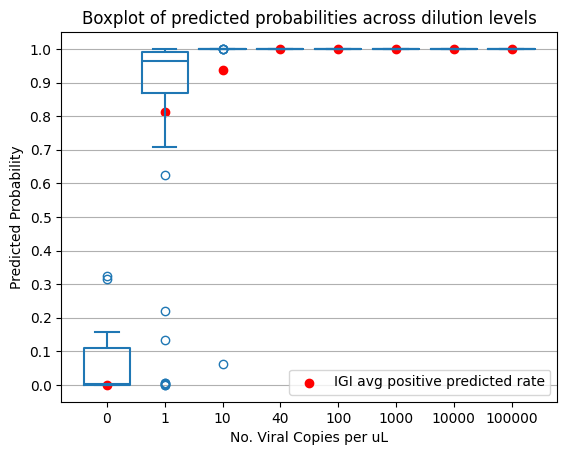

In [18]:
# boxplot_df = pd.concat([known_pred_df[['dilution_level','outputs']], water_output_df[['dilution_level','outputs']]], axis=0)
boxplot_df = pd.concat([boxplot_known_df[['curve_idx','well_position','dilution_level','outputs','pred','new_igi_call','prob','qpcr_pred','deepnet_pred','humanbased_pred']], 
                        water_output_df[['curve_idx','well_position','dilution_level','outputs','pred','new_igi_call','prob','qpcr_pred','deepnet_pred','humanbased_pred']]], axis=0)

sns.boxplot(data=boxplot_df, x='dilution_level', y = 'outputs', fill = False)
plt.scatter(0, water_output_df.groupby('curve_idx').new_igi_call.mean().mean(), color = 'red', label = 'IGI avg positive predicted rate')
plt.scatter(1, boxplot_known_df[boxplot_known_df.dilution_level == 1].new_igi_call.mean(), color = 'red')
plt.scatter(2, boxplot_known_df[boxplot_known_df.dilution_level == 10].new_igi_call.mean(), color = 'red')
plt.scatter(3, boxplot_known_df[boxplot_known_df.dilution_level == 40].new_igi_call.mean(), color = 'red')
plt.scatter(4, boxplot_known_df[boxplot_known_df.dilution_level == 100].new_igi_call.mean(), color = 'red')
plt.scatter(5, boxplot_known_df[boxplot_known_df.dilution_level == 1000].new_igi_call.mean(), color = 'red')
plt.scatter(6, boxplot_known_df[boxplot_known_df.dilution_level == 10000].new_igi_call.mean(), color = 'red')
plt.scatter(7, boxplot_known_df[boxplot_known_df.dilution_level == 100000].new_igi_call.mean(), color = 'red')

plt.title('Boxplot of predicted probabilities across dilution levels')
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

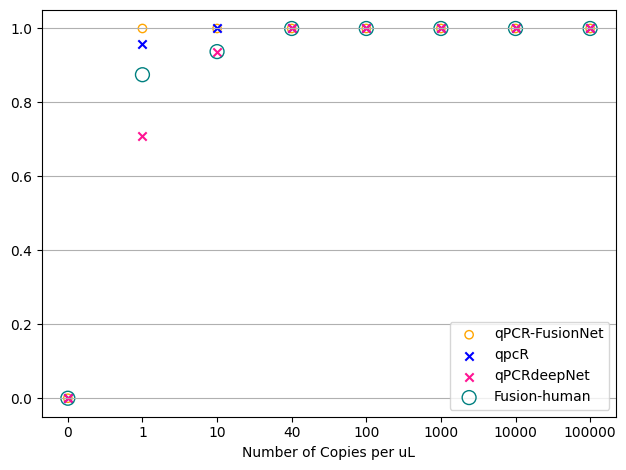

In [19]:
color_map = {'igi': '#008080',
             'fusion': '#ffa500',
             'qpcr':'#00ff00',
             'deepnet': '#0000ff',
             'humanbased': '#ff1493'
             }

known_sampled_pred = (boxplot_df
                      .groupby(['dilution_level', 'well_position'])
                      .agg(sample_pred = ('pred', 'mean'),
                           sample_igi_call = ('new_igi_call', 'mean'),
                           sample_qpcr_pred = ('qpcr_pred','mean'),
                           sample_deepnet_pred = ('deepnet_pred','mean'),
                           sample_humanbased_pred = ('humanbased_pred','mean'),
                           )
                      .reset_index())
known_sampled_pred['sample_pred'] = 1*(known_sampled_pred.sample_pred >= 0.5)
known_sampled_pred['sample_igi_call'] = 1*(known_sampled_pred.sample_igi_call >= 0.5)
known_sampled_pred['sample_qpcr_pred'] = 1*(known_sampled_pred.sample_qpcr_pred >= 0.5)
known_sampled_pred['sample_deepnet_pred'] = 1*(known_sampled_pred.sample_deepnet_pred >= 0.5)
known_sampled_pred['sample_humanbased_pred'] = 1*(known_sampled_pred.sample_humanbased_pred >= 0.5)

pos_known_pred = known_sampled_pred.groupby('dilution_level')[['sample_igi_call','sample_pred','sample_qpcr_pred','sample_deepnet_pred','sample_humanbased_pred']].apply(lambda x: x.sum()/len(x)).reset_index()
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')

plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_pred', facecolor='none', edgecolor = color_map.get('fusion'))
# plt.scatter(data=pos_known_pred,
#              x='dilution_level', y='sample_qpcr_pred', color = color_map.get('qpcr'), marker='^')
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_deepnet_pred', color = color_map.get('deepnet'), marker='x')
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_humanbased_pred', color = color_map.get('humanbased'), marker='x')
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_igi_call', facecolor='none', edgecolors=color_map.get('igi'), s = 100)
# plt.scatter(x=pos_known_pred.dilution_level, y='qpcr_pred', marker='x')
plt.legend(labels=['qPCR-FusionNet','qpcR','qPCRdeepNet','Fusion-human','Estimated IGI'])
# plt.title('Proportion of predicted positive samples in dilution level')
plt.xlabel('Number of Copies per uL')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('known_sample_pred.png')

print()

In [20]:
known_sampled_pred[(known_sampled_pred['dilution_level']<=10)&(known_sampled_pred['dilution_level']>0)][['sample_igi_call','sample_pred','sample_qpcr_pred','sample_deepnet_pred','sample_humanbased_pred']].mean()

sample_igi_call           0.900
sample_pred               1.000
sample_qpcr_pred          0.975
sample_deepnet_pred       0.975
sample_humanbased_pred    0.800
dtype: float64

In [21]:
pos_known_pred

,dilution_level,sample_igi_call,sample_pred,sample_qpcr_pred,sample_deepnet_pred,sample_humanbased_pred
0,0,0.0000,0.0,0.000000,0.000000,0.000000
1,1,0.8750,1.0,0.958333,0.958333,0.708333
2,10,0.9375,1.0,1.000000,1.000000,0.937500
3,40,1.0000,1.0,1.000000,1.000000,1.000000
4,100,1.0000,1.0,1.000000,1.000000,1.000000
5,1000,1.0000,1.0,1.000000,1.000000,1.000000
6,10000,1.0000,1.0,1.000000,1.000000,1.000000
7,100000,1.0000,1.0,1.000000,1.000000,1.000000


In [22]:
print(boxplot_df.shape)
print(known_sampled_pred.shape)

(217, 10)
(104, 7)


In [23]:
boxplot_df['groundtruth_label'] = 1*(boxplot_df.dilution_level != 0)
known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.outputs)
print('Model AUC on known:', known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.pred)

Model AUC on known: 0.9820833333333332


,acc,f1,tn,fp,fn,tp
0,0.963134,0.978723,25,0,8,184


In [24]:

igi_known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)
print('IGI AUC on known:', igi_known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)

IGI AUC on known: 0.9713541666666667


,acc,f1,tn,fp,fn,tp
0,0.949309,0.970509,25,0,11,181


In [25]:
print(known_sampled_pred.well_position.nunique())
summary_table(boxplot_df)

104


,n_curves,pos_perc
0,217,0.884793


### chip60

In [26]:
chip60_pred_df = (chip60_pred
                  .merge(chip60_df[chip60_df['Index'] == 1], on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

chip60_boxplot = (chip60_pred_df[['curve_idx','dilution','groundtruth_label','outputs']]
                  #.merge(chip60_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .merge(chip60_deep_pred[['curve_idx', 'probability']], on='curve_idx')
                  .merge(chip60_humanbased_pred[['curve_idx', 'outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                  .melt(id_vars=['curve_idx','dilution','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
chip60_boxplot['model'] = chip60_boxplot.model.replace({'outputs':'qPCR-FusionNet',
                                                        'prob':'qpcR',
                                                        'probability':'qPCRdeepNet',
                                                        'human_prob':'Fusion-human'})

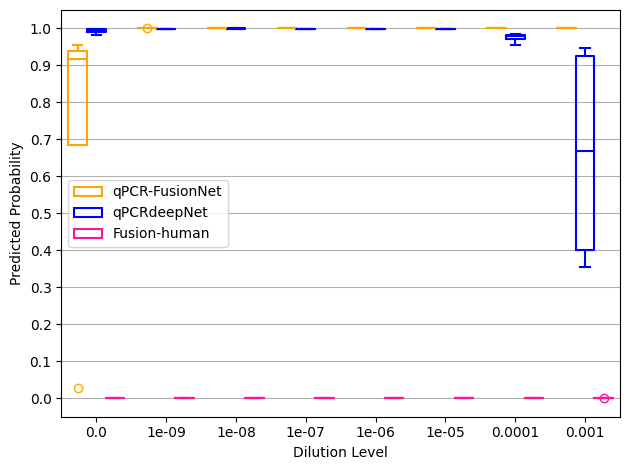

In [45]:
color_map = {'IGI': '#008080',
             'qPCR-FusionNet': '#ffa500',
             #'qpcR':'#00ff00',
             'qPCRdeepNet': '#0000ff',
             'Fusion-human': '#ff1493'
             }
g = sns.boxplot(data=chip60_boxplot, x='dilution', y = 'predicted_score', hue='model', 
            palette=color_map, fill = False)

# plt.axhline(y=best_test_acc_thres, color='blue', linestyle = '--')
# plt.text(x=4, y = best_test_acc_thres - 0.05, s='Best accuracy threshold on test set', c='blue', size=8)

# plt.title('Boxplot of predicted probabilities across dilution levels on chip60')
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('Dilution Level')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend() #labels=['Fusion','qpcR','qPCRdeepNet'])
plt.tight_layout()
plt.savefig('chip60_prob_boxplot.png')


In [34]:
chip60_boxplot_Fusion = chip60_boxplot[chip60_boxplot['model']=='qPCR-FusionNet'] 
chip60_boxplot_qPCRdeepNet = chip60_boxplot[chip60_boxplot['model']=='qPCR-FusionNet'] 
chip60_boxplot_FusionHuman = chip60_boxplot[chip60_boxplot['model']=='Fusion-human'] 

print(chip60_boxplot)

    curve_idx      dilution  groundtruth_label           model  \
0     Vim.0.1  0.000000e+00                  0  qPCR-FusionNet   
1   MLC2v.4.1  1.000000e-06                  1  qPCR-FusionNet   
2     Vim.6.1  1.000000e-08                  1  qPCR-FusionNet   
3     Vim.7.1  1.000000e-09                  1  qPCR-FusionNet   
4     Vim.1.2  1.000000e-03                  1  qPCR-FusionNet   
..        ...           ...                ...             ...   
91  MLC2v.5.2  1.000000e-07                  1    Fusion-human   
92  MLC2v.4.2  1.000000e-06                  1    Fusion-human   
93    Vim.2.2  1.000000e-04                  1    Fusion-human   
94    Vim.7.2  1.000000e-09                  1    Fusion-human   
95  MLC2v.3.2  1.000000e-05                  1    Fusion-human   

    predicted_score  pred  model_pred  
0          0.955537     1           1  
1          1.000000     1           1  
2          1.000000     1           1  
3          1.000000     1           1  
4      

In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# # You can now use the updated 'model_pred' column for further analysis

# def calculate_metrics(df, model_name, threshold):
#     model_df = df[df['model'] == model_name]
#     y_true = model_df['groundtruth_label']
#     y_pred = (model_df['predicted_score'] >= threshold).astype(int)
#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#     sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
#     specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
#     youden_index = sensitivity + specificity - 1
#     accuracy = accuracy_score(y_true, y_pred)
#     return youden_index, accuracy

# def find_optimal_threshold(df, model_name, criterion='youden'):
#     model_df = df[df['model'] == model_name]
#     thresholds = np.sort(model_df['predicted_score'].unique())
#     metrics = [calculate_metrics(df, model_name, threshold) for threshold in thresholds]
#     youden_indices, accuracies = zip(*metrics)
    
#     if criterion == 'youden':
#         optimal_index = np.argmax(youden_indices)
#     elif criterion == 'accuracy':
#         optimal_index = np.argmax(accuracies)
#     else:
#         raise ValueError("Invalid criterion. Choose 'youden' or 'accuracy'.")
    
#     return thresholds[optimal_index], youden_indices[optimal_index], accuracies[optimal_index]

# def optimize_thresholds(df,criterion):
#     optimal_thresholds = {}
#     for model in model_names:
#         threshold, youden_index, accuracy = find_optimal_threshold(df, model, criterion)
#         optimal_thresholds[model] = {
#             'threshold': threshold,
#             'youden_index': youden_index,
#             'accuracy': accuracy
#         }
    
#     # Print results
#     print(f"Optimization criterion: {criterion}")
#     for model, results in optimal_thresholds.items():
#         print(f"Model: {model}")
#         print(f"Optimal Threshold: {results['threshold']:.6f}")
#         print(f"Youden Index: {results['youden_index']:.6f}")
#         print(f"Accuracy: {results['accuracy']:.6f}")
#         print()
    
#     # Update the 'model_pred' column based on optimal thresholds
#     for model, results in optimal_thresholds.items():
#         mask = (df['model'] == model)
#         df.loc[mask, f'model_pred_{criterion}'] = (df.loc[mask, 'predicted_score'] >= results['threshold']).astype(int)

# # Optimize for Youden Index
# #optimize_thresholds('youden')

# # Optimize for Accuracy
# model_names = chip60_boxplot['model'].unique()
# optimize_thresholds(chip60_boxplot,'accuracy')

# You can now use the updated 'model_pred_youden' and 'model_pred_accuracy' columns for further analysis

def calculate_metrics(df, model_name, threshold):
    model_df = df[df['model'] == model_name]
    y_true = model_df['groundtruth_label']
    y_pred = (model_df['predicted_score'] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_index = sensitivity + specificity - 1
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return youden_index, accuracy, f1

def find_optimal_threshold(df, model_name, criterion='youden'):
    model_df = df[df['model'] == model_name]
    thresholds = np.sort(model_df['predicted_score'].unique())
    metrics = [calculate_metrics(df, model_name, threshold) for threshold in thresholds]
    youden_indices, accuracies, f1_scores = zip(*metrics)
    
    if criterion == 'youden':
        optimal_index = np.argmax(youden_indices)
    elif criterion == 'accuracy':
        optimal_index = np.argmax(accuracies)
    elif criterion == 'f1':
        optimal_index = np.argmax(f1_scores)
    else:
        raise ValueError("Invalid criterion. Choose 'youden', 'accuracy', or 'f1'.")
    
    return thresholds[optimal_index], youden_indices[optimal_index], accuracies[optimal_index], f1_scores[optimal_index]

def optimize_thresholds(df,criterion):
    optimal_thresholds = {}
    for model in model_names:
        threshold, youden_index, accuracy, f1 = find_optimal_threshold(df, model, criterion)
        optimal_thresholds[model] = {
            'threshold': threshold,
            'youden_index': youden_index,
            'accuracy': accuracy,
            'f1_score': f1
        }
    
    # Print results
    print(f"Optimization criterion: {criterion}")
    for model, results in optimal_thresholds.items():
        print(f"Model: {model}")
        print(f"Optimal Threshold: {results['threshold']:.6f}")
        print(f"Youden Index: {results['youden_index']:.6f}")
        print(f"Accuracy: {results['accuracy']:.6f}")
        print(f"F1 Score: {results['f1_score']:.6f}")
        print()
    
    # Update the 'model_pred' column based on optimal thresholds
    for model, results in optimal_thresholds.items():
        mask = (df['model'] == model)
        df.loc[mask, f'model_pred_{criterion}'] = (df.loc[mask, 'predicted_score'] >= results['threshold']).astype(int)

# Assuming your DataFrame is named 'df'
model_names = chip60_boxplot['model'].unique()

# Optimize for F1 Score
optimize_thresholds(chip60_boxplot,'f1')
optimize_thresholds(chip60_boxplot,'youden')

chip60_boxplot


Optimization criterion: f1
Model: qPCR-FusionNet
Optimal Threshold: 0.999978
Youden Index: 1.000000
Accuracy: 1.000000
F1 Score: 1.000000

Model: qPCRdeepNet
Optimal Threshold: 0.355068
Youden Index: 0.000000
Accuracy: 0.875000
F1 Score: 0.933333

Model: Fusion-human
Optimal Threshold: 0.000160
Youden Index: 0.000000
Accuracy: 0.875000
F1 Score: 0.933333

Optimization criterion: youden
Model: qPCR-FusionNet
Optimal Threshold: 0.999978
Youden Index: 1.000000
Accuracy: 1.000000
F1 Score: 1.000000

Model: qPCRdeepNet
Optimal Threshold: 0.999853
Youden Index: 0.500000
Accuracy: 0.562500
F1 Score: 0.666667

Model: Fusion-human
Optimal Threshold: 0.000160
Youden Index: 0.750000
Accuracy: 0.781250
F1 Score: 0.857143



,curve_idx,dilution,groundtruth_label,model,predicted_score,pred,model_pred,model_pred_accuracy,model_pred_f1,model_pred_youden
0,Vim.0.1,0.000000e+00,0,qPCR-FusionNet,0.955537,1,1,0.0,0.0,0.0
1,MLC2v.4.1,1.000000e-06,1,qPCR-FusionNet,1.000000,1,1,1.0,1.0,1.0
2,Vim.6.1,1.000000e-08,1,qPCR-FusionNet,1.000000,1,1,1.0,1.0,1.0
3,Vim.7.1,1.000000e-09,1,qPCR-FusionNet,1.000000,1,1,1.0,1.0,1.0
4,Vim.1.2,1.000000e-03,1,qPCR-FusionNet,1.000000,1,1,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
91,MLC2v.5.2,1.000000e-07,1,Fusion-human,0.000160,0,0,1.0,1.0,0.0
92,MLC2v.4.2,1.000000e-06,1,Fusion-human,0.000160,0,0,1.0,1.0,1.0
93,Vim.2.2,1.000000e-04,1,Fusion-human,0.000160,0,0,1.0,1.0,1.0
94,Vim.7.2,1.000000e-09,1,Fusion-human,0.000160,0,0,1.0,1.0,1.0


In [55]:
# chip60_boxplot['pred'] = 0
# chip60_boxplot.loc[chip60_boxplot.model == 'qPCR-FusionNet', 'pred'] = chip60_boxplot.model_pred_accuracy
# chip60_boxplot.loc[chip60_boxplot.model == 'qpcR', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_qpcr_test_acc_thres)
# chip60_boxplot.loc[chip60_boxplot.model == 'qpcR', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_qpcr_test_acc_thres)
                   
chip60_avg_pred_score = chip60_boxplot.groupby(['dilution','model'])[['groundtruth_label','model_pred_youden']].apply(lambda x: accuracy_score(x.groundtruth_label, x.model_pred_youden)).reset_index()
chip60_avg_pred_score.columns = ['dilution','model','accuracy_score']
chip60_avg_pred_score['dilution'] = chip60_avg_pred_score.dilution.astype('str')
chip60_avg_pred_score

,dilution,model,accuracy_score
0,0.0,Fusion-human,1.00
1,0.0,qPCR-FusionNet,1.00
2,0.0,qPCRdeepNet,1.00
3,1e-09,Fusion-human,0.50
4,1e-09,qPCR-FusionNet,1.00
5,1e-09,qPCRdeepNet,1.00
6,1e-08,Fusion-human,1.00
7,1e-08,qPCR-FusionNet,1.00
8,1e-08,qPCRdeepNet,1.00
9,1e-07,Fusion-human,0.50


In [60]:
# Calculate the mean of model_pred_youden for each model and dilution level
chip60_avg_pred_score = chip60_boxplot.groupby(['dilution', 'model'])['model_pred_youden'].mean().reset_index()

# Sort the DataFrame if needed
chip60_avg_pred_score = chip60_avg_pred_score.sort_values(['model', 'dilution'])
chip60_avg_pred_score['dilution'] = chip60_avg_pred_score.dilution.astype('str')
chip60_avg_pred_score

,dilution,model,model_pred_youden
0,0.0,Fusion-human,0.00
3,1e-09,Fusion-human,0.50
6,1e-08,Fusion-human,1.00
9,1e-07,Fusion-human,0.50
12,1e-06,Fusion-human,1.00
15,1e-05,Fusion-human,0.75
18,0.0001,Fusion-human,0.50
21,0.001,Fusion-human,1.00
1,0.0,qPCR-FusionNet,0.00
4,1e-09,qPCR-FusionNet,1.00


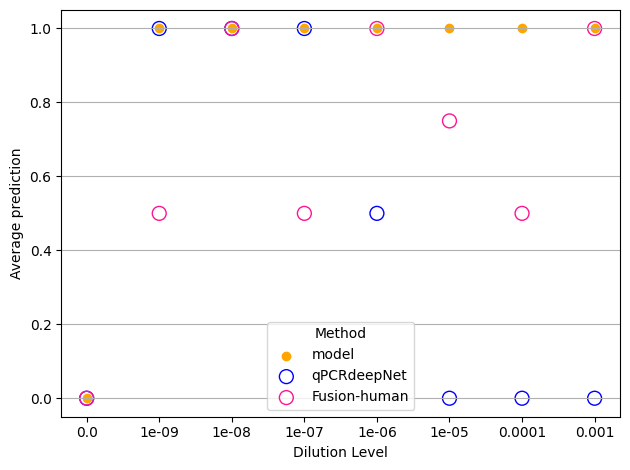

In [67]:
color_map = {'IGI': '#008080',
             'qPCR-FusionNet': '#ffa500',
             #'qpcR':'#00ff00',
             'qPCRdeepNet': '#0000ff',
             'Fusion-human': '#ff1493'
             }

plt.scatter(chip60_avg_pred_score[chip60_avg_pred_score.model == 'qPCR-FusionNet'].dilution, 
            chip60_avg_pred_score[chip60_avg_pred_score.model == 'qPCR-FusionNet'].model_pred_youden, c = '#ffa500', label='model')

plt.scatter(chip60_avg_pred_score[chip60_avg_pred_score.model == 'qPCRdeepNet'].dilution, 
            chip60_avg_pred_score[chip60_avg_pred_score.model == 'qPCRdeepNet'].model_pred_youden, 
            s=100, facecolor='none', edgecolors='#0000ff', label='qPCRdeepNet')

plt.scatter(chip60_avg_pred_score[chip60_avg_pred_score.model == 'Fusion-human'].dilution, 
            chip60_avg_pred_score[chip60_avg_pred_score.model == 'Fusion-human'].model_pred_youden, 
            s=100, facecolor='none', edgecolors='#ff1493', label='Fusion-human')
plt.xlabel('Dilution Level')
plt.ylabel('Average prediction')
plt.legend(title='Method')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('chip60_pred_by_class')

In [63]:
# Calculate the accuracy for each model
model_accuracy = chip60_boxplot.groupby('model').apply(
    lambda x: accuracy_score(x['groundtruth_label'], x['model_pred_youden'])
).reset_index()
model_accuracy.columns = ['model', 'accuracy']

# Sort the results by accuracy in descending order
model_accuracy = model_accuracy.sort_values('accuracy', ascending=False)

# Display the results
print("Accuracy per model:")
print(model_accuracy)

Accuracy per model:
            model  accuracy
1  qPCR-FusionNet   1.00000
0    Fusion-human   0.78125
2     qPCRdeepNet   0.56250


In [41]:

model_chip_auc = roc_auc_score(chip60_boxplot[chip60_boxplot.model == 'qPCR-FusionNet'].groundtruth_label, 
                             chip60_boxplot[chip60_boxplot.model == 'qPCR-FusionNet'].predicted_score)
print('Model AUC on chip60:', model_chip_auc)
chip60_boxplot['model_pred'] = 1*(chip60_boxplot.predicted_score >= best_test_acc_thres)
calc_metrics(chip60_boxplot[chip60_boxplot.model == 'qPCR-FusionNet'].groundtruth_label, 
             chip60_boxplot[chip60_boxplot.model == 'qPCR-FusionNet'].model_pred)

Model AUC on chip60: 1.0


,acc,f1,tn,fp,fn,tp
0,0.90625,0.949153,1,3,0,28


In [32]:

qpcr_chip_auc = roc_auc_score(chip60_boxplot[chip60_boxplot.model == 'qpcR'].groundtruth_label, 
                             chip60_boxplot[chip60_boxplot.model == 'qpcR'].predicted_score)
print('qpcR AUC on karlen:', qpcr_chip_auc)
chip60_boxplot['qpcr_pred'] = 1*(chip60_boxplot.predicted_score >= 0.5)
calc_metrics(chip60_boxplot[chip60_boxplot.model == 'qpcR'].groundtruth_label, 
             chip60_boxplot[chip60_boxplot.model == 'qpcR'].qpcr_pred)

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
summary_table(chip60_boxplot)

,n_curves,pos_perc
0,32,0.875


### karlen

In [ ]:
karlen_pred_df = (karlen_pred
                  .merge(karlen_df[karlen_df.Cycles == 1], on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

karlen_boxplot = (karlen_pred_df[['curve_idx','inv_dilution_fold','dilution_fold','groundtruth_label','outputs']]
                  .merge(karlen_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .merge(karlen_deep_pred[['curve_idx', 'probability']], on='curve_idx')
                  .merge(karlen_humanbased_pred[['curve_idx', 'outputs']].rename(columns={'outputs':'human_prob'}), on='curve_idx')
                  .melt(id_vars=['curve_idx','inv_dilution_fold','dilution_fold','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
karlen_boxplot['model'] = karlen_boxplot.model.replace({'outputs':'qPCR-FusionNet',
                                                        'prob':'qpcR',
                                                        'probability':'qPCRdeepNet',
                                                        'human_prob':'Fusion-human'})
# karlen_boxplot['inv_dilution_fold'] = 1/karlen_boxplot.dilution_fold
# karlen_boxplot['inv_dilution_fold'] = karlen_boxplot.inv_dilution_fold.astype('str')

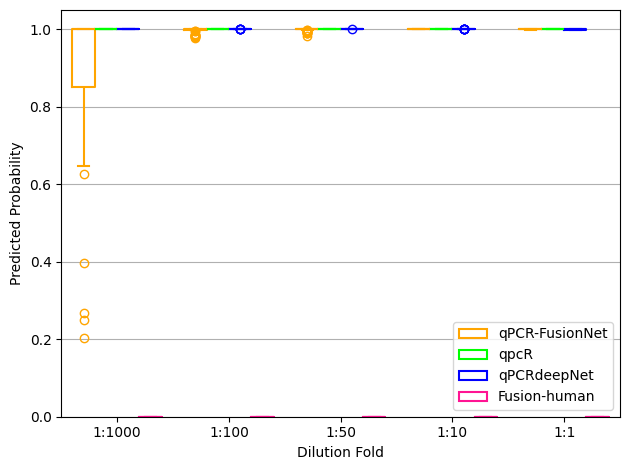

In [ ]:
sns.boxplot(data=karlen_boxplot, x='inv_dilution_fold', y = 'predicted_score', 
            hue='model', palette=color_map, fill = False)

# plt.axhline(y=best_test_acc_thres, color='blue', linestyle = '--')
# plt.text(x=0, y = best_test_acc_thres - 0.05, s='Best accuracy threshold on test set', c='blue', size=8)

# plt.title('Boxplot of predicted probabilities across dilution levels on karlen')
plt.xlabel('Dilution Fold')
plt.xticks(ticks=range(5), labels=['1:' + str(d) for d in [1000, 100, 50, 10, 1]])
plt.ylabel('Predicted Probability')
plt.ylim(0,1.05)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/karlen_prob_boxplot.png')

Text(0.5, 1.0, 'Accuracy by Dilution Levels on karlen')

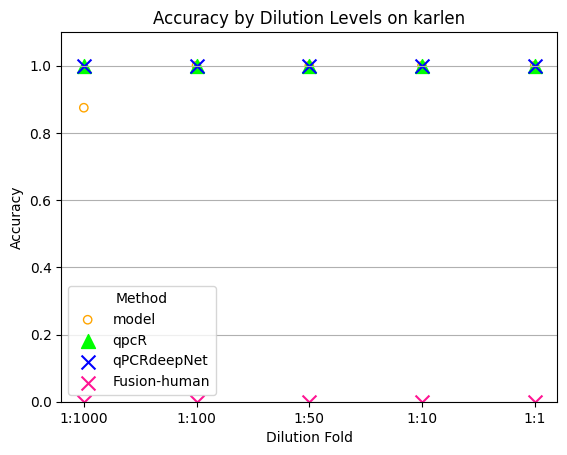

In [ ]:
karlen_boxplot['pred'] = 0
karlen_boxplot.loc[karlen_boxplot.model == 'qPCR-FusionNet', 'pred'] = 1*(karlen_boxplot.predicted_score >= best_test_acc_thres)
karlen_boxplot.loc[karlen_boxplot.model == 'qPCRdeepNet', 'pred'] = 1*(karlen_boxplot.predicted_score >= best_deepnet_test_acc_thres)
karlen_boxplot.loc[karlen_boxplot.model == 'qpcR', 'pred'] = 1*(karlen_boxplot.predicted_score >= best_qpcr_test_acc_thres)
karlen_boxplot.loc[karlen_boxplot.model == 'qpFusion-humancR', 'pred'] = 1*(karlen_boxplot.predicted_score >= best_humanbased_test_acc_thres)
                   
karlen_avg_pred_score = (karlen_boxplot
                         .groupby(['inv_dilution_fold','dilution_fold','model'])[['groundtruth_label','pred']]
                         .apply(lambda x: accuracy_score(x.groundtruth_label, x.pred)).reset_index())
karlen_avg_pred_score.columns = ['inv_dilution_fold','dilution_fold','model','accuracy_score']

plt.scatter(karlen_avg_pred_score[karlen_avg_pred_score.model == 'qPCR-FusionNet'].inv_dilution_fold.astype(str), 
            karlen_avg_pred_score[karlen_avg_pred_score.model == 'qPCR-FusionNet'].accuracy_score, 
            facecolor='none', edgecolors=color_map.get('qPCR-FusionNet'), label='model')
plt.scatter(karlen_avg_pred_score[karlen_avg_pred_score.model == 'qpcR'].inv_dilution_fold.astype(str), 
            karlen_avg_pred_score[karlen_avg_pred_score.model == 'qpcR'].accuracy_score, 
            s=100, marker='^', c=color_map.get('qpcR'), label='qpcR')
plt.scatter(karlen_avg_pred_score[karlen_avg_pred_score.model == 'qPCRdeepNet'].inv_dilution_fold.astype(str), 
            karlen_avg_pred_score[karlen_avg_pred_score.model == 'qPCRdeepNet'].accuracy_score, 
            s=100, marker='x', c=color_map.get('qPCRdeepNet'), label='qPCRdeepNet')
plt.scatter(karlen_avg_pred_score[karlen_avg_pred_score.model == 'Fusion-human'].inv_dilution_fold.astype(str), 
            karlen_avg_pred_score[karlen_avg_pred_score.model == 'Fusion-human'].accuracy_score, 
            s=100, marker='x', c=color_map.get('Fusion-human'), label='Fusion-human')
plt.xlabel('Dilution Fold')
plt.xticks(ticks=range(len(karlen_avg_pred_score.dilution_fold.unique())), labels=['1:' + str(d) for d in karlen_avg_pred_score.dilution_fold.unique()])
plt.ylabel('Accuracy')
plt.ylim(0,1.1)
plt.legend(title='Method')
plt.grid(axis='y')
plt.title('Accuracy by Dilution Levels on karlen')

### IGI Simulation
##### karlen

In [ ]:
karlen_pred_full = karlen_pred.copy()
karlen_pred_full = (karlen_df
               .merge(karlen_pred_full[['curve_idx','outputs']], on='curve_idx'))

In [ ]:
thermo_df = join_df[(join_df.test_kit == 'Thermo') & (join_df.cycle_no == 37)]
thermo_threshold_df = thermo_df.groupby('target').threshold.mean()

thermo_thres_perc_df = pd.DataFrame(thermo_threshold_df)
thermo_thres_perc_df['percentile'] = np.nan
for key in thermo_thres_perc_df.index:
    thermo_thres_perc_df.loc[key,'percentile'] = percentileofscore(thermo_df[thermo_df.target == key].drn, 
                                                         thermo_threshold_df[key], kind='weak')

threshold_40 = thermo_thres_perc_df.percentile.mean()

karlen_threshold = (karlen_pred_full[karlen_pred_full.Cycles == 37]
                    .groupby('data_set')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_40))
                    .reset_index(name='threshold'))

karlen_pred_full = (karlen_pred_full
             .merge(karlen_threshold, on = 'data_set'))

karlen_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_pred_full['pred'] = 1*(karlen_pred_full.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_pred_full.groundtruth_label, karlen_pred_full.pred, labels=np.array([0,1])).ravel()
    
    karlen_model_dict['thres'].append(i)
    karlen_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_model_dict['fnr'].append(fn/(fn+tp))
    karlen_model_dict['fpr'].append(fp/(fp+tn))
    karlen_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_model_dict_df = pd.DataFrame(karlen_model_dict)
    
karlen_thres_df = {'perc':[], 'cycle':[], 'acc':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(31, 41):
        df = karlen_pred_full.copy()
        df['new_threshold'] = karlen_pred_full.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)

        tn, fp, fn, tp = confusion_matrix(df[df.Cycles == 1].groundtruth_label, df[df.Cycles == 1].new_igi_call, labels=np.array([0,1])).ravel()
        
        karlen_thres_df['perc'].append(perc)
        karlen_thres_df['cycle'].append(cycle)
        karlen_thres_df['acc'].append((tp+tn)/(tp+fp+tn+fn))
        karlen_thres_df['fpr'].append(fp/(fp+tn))
        karlen_thres_df['fnr'].append(fn/(fn+tp))
        karlen_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))


/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1416774202.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr

In [ ]:

karlen_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_qpcr_pred['pred'] = 1*(karlen_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_qpcr_pred.groundtruth_label, karlen_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_qpcr_dict['thres'].append(i)
    karlen_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_qpcr_dict['fnr'].append(fn/(fn+tp))
    karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
    karlen_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_qpcr_dict_df = pd.DataFrame(karlen_qpcr_dict)

/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(

/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(

In [ ]:

karlen_deepnet_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_deep_pred['pred'] = 1*(karlen_deep_pred.probability >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_deep_pred.groundtruth_label, karlen_deep_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_deepnet_dict['thres'].append(i)
    karlen_deepnet_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_deepnet_dict['fnr'].append(fn/(fn+tp))
    karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
    karlen_deepnet_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_deepnet_dict_df = pd.DataFrame(karlen_deepnet_dict)

/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_di

/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/1886161962.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_deepnet_di

In [ ]:

karlen_humanbased_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_humanbased_pred['pred'] = 1*(karlen_humanbased_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_humanbased_pred.groundtruth_label, karlen_humanbased_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_humanbased_dict['thres'].append(i)
    karlen_humanbased_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_humanbased_dict['fnr'].append(fn/(fn+tp))
    karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
    karlen_humanbased_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_humanbased_dict_df = pd.DataFrame(karlen_humanbased_dict)

/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
 

/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_humanbased_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_1758563/3994924458.py:9: RuntimeWarning: invalid value encountered in scalar divide
 

True positive fraction: 1.0


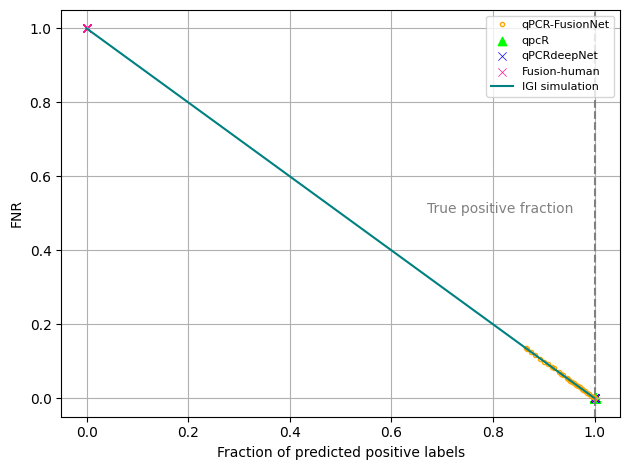

In [ ]:
        
karlen_true_pos_frac = sum(karlen_pred_full.groundtruth_label == 1)/karlen_pred_full.shape[0]
print('True positive fraction:', karlen_true_pos_frac)
karlen_thres_df = pd.DataFrame(karlen_thres_df)

plt.plot(karlen_model_dict_df[['pos_frac','fnr']].drop_duplicates().pos_frac, 
         karlen_model_dict_df[['pos_frac','fnr']].drop_duplicates().fnr, 
        #   'o', **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
        marker='o', markersize=3, fillstyle='none', linestyle='none', color=color_map.get('qPCR-FusionNet'),
         linewidth=0.5,
         label='qPCR-FusionNet')
plt.scatter(karlen_qpcr_dict_df.pos_frac, karlen_qpcr_dict_df.fnr, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(karlen_deepnet_dict_df.pos_frac, karlen_deepnet_dict_df.fnr, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidths=0.5, label='qPCRdeepNet')
plt.scatter(karlen_humanbased_dict_df.pos_frac, karlen_humanbased_dict_df.fnr, 
            color=color_map.get('Fusion-human'), marker='x', linewidths=0.5, label='Fusion-human')
plt.plot(karlen_thres_df.pos_pred, 
         karlen_thres_df.fnr, 
         color=color_map.get('IGI'), label='IGI simulation')
plt.axvline(karlen_true_pos_frac, linestyle='--', color='gray')
plt.text(x=karlen_true_pos_frac - 0.33, y = 0.5, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
# plt.title('FNR of different methods when varying thresholds on karlen set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_qpcr_karlen.png')

#### Chip60

In [ ]:
chip60_pred_full = chip60_pred.copy()
chip60_pred_full = (chip60_pred_full
                    .merge(chip60_df, on='curve_idx'))

In [ ]:
luner_df = join_df[(join_df.test_kit == 'LuNER') & (join_df.cycle_no == 40)]
luner_threshold_df = luner_df.groupby('target').threshold.mean()

luner_thres_perc_df = pd.DataFrame(luner_threshold_df)
luner_thres_perc_df['percentile'] = np.nan
for key in luner_thres_perc_df.index:
    luner_thres_perc_df.loc[key,'percentile'] = percentileofscore(luner_df[luner_df.target == key].drn, 
                                                         luner_threshold_df[key], kind='weak')

threshold_45 = luner_thres_perc_df.percentile.mean()

chip60_threshold = (chip60_pred_full[chip60_pred_full['Index'] == 40]
                    .groupby('sample')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_45))
                    .reset_index(name='threshold'))

chip60_pred_full_df = (chip60_pred_full
             .merge(chip60_threshold, on = 'sample'))

chip60_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_pred_full_df['pred'] = 1*(chip60_pred_full_df.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_pred_full_df.groundtruth_label, chip60_pred_full_df.pred, labels=np.array([0,1])).ravel()
    
    chip60_model_dict['thres'].append(i)
    chip60_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_model_dict['fnr'].append(fn/(fn+tp))
    chip60_model_dict['fpr'].append(fp/(fp+tn))
    chip60_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_model_dict_df = pd.DataFrame(chip60_model_dict)
    

chip60_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_qpcr_pred['pred'] = 1*(chip60_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_qpcr_pred.groundtruth_label, chip60_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_qpcr_dict['thres'].append(i)
    chip60_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_qpcr_dict['fnr'].append(fn/(fn+tp))
    chip60_qpcr_dict['fpr'].append(fp/(fp+tn))
    chip60_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_qpcr_dict_df = pd.DataFrame(chip60_qpcr_dict)
    
chip60_deepnet_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_deep_pred['pred'] = 1*(chip60_deep_pred.probability >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_deep_pred.groundtruth_label, chip60_deep_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_deepnet_dict['thres'].append(i)
    chip60_deepnet_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_deepnet_dict['fnr'].append(fn/(fn+tp))
    chip60_deepnet_dict['fpr'].append(fp/(fp+tn))
    chip60_deepnet_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_deepnet_dict_df = pd.DataFrame(chip60_deepnet_dict)
    
chip60_humanbased_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_humanbased_pred['pred'] = 1*(chip60_humanbased_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_humanbased_pred.groundtruth_label, chip60_humanbased_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_humanbased_dict['thres'].append(i)
    chip60_humanbased_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_humanbased_dict['fnr'].append(fn/(fn+tp))
    chip60_humanbased_dict['fpr'].append(fp/(fp+tn))
    chip60_humanbased_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_humanbased_dict_df = pd.DataFrame(chip60_humanbased_dict)

chip60_thres_df = {'perc':[], 'cycle':[], 'acc':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(35, 45):
        df = chip60_pred_full_df.copy()
        df['new_threshold'] = chip60_pred_full_df.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)
        df_1 = df[df['Index'] == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        chip60_thres_df['perc'].append(perc) #[perc]*len(tn)
        chip60_thres_df['cycle'].append(cycle) #[cycle]*len(tn)
        chip60_thres_df['fpr'].append(fp/(fp+tn))
        chip60_thres_df['acc'].append((tp+tn)/(tp+fp+tn+fn))
        chip60_thres_df['fnr'].append(fn/(fn+tp))
        chip60_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
chip60_true_pos_frac = sum(chip60_pred_full_df.groundtruth_label == 1)/chip60_pred_full_df.shape[0]
print('True positive fraction:', chip60_true_pos_frac)

chip60_thres_df = pd.DataFrame(chip60_thres_df)


True positive fraction: 0.875


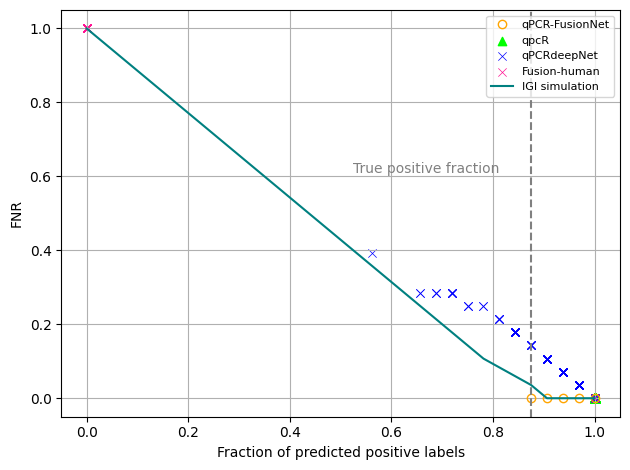

In [ ]:

plt.plot(chip60_model_dict_df[['pos_frac','fnr']].drop_duplicates().pos_frac, 
         chip60_model_dict_df[['pos_frac','fnr']].drop_duplicates().fnr, 
         marker='o', fillstyle='none', linestyle='none', 
         color=color_map.get('qPCR-FusionNet'), linewidth=0.0005,
        #  **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
         label='qPCR-FusionNet')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fnr, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(chip60_deepnet_dict_df.pos_frac, chip60_deepnet_dict_df.fnr, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidth=0.5,
            # 'x', **{'mfc': 'none', 'mec':color_map.get('qPCRdeepNet'),'mew':0.8},
            label='qPCRdeepNet')
plt.scatter(chip60_humanbased_dict_df.pos_frac, chip60_humanbased_dict_df.fnr, 
            color=color_map.get('Fusion-human'), marker='x', linewidth=0.5,
            label='Fusion-human')

plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fnr, 
         color=color_map.get('IGI'), label='IGI simulation')

# plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')



plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
# plt.title('FNR of different methods when varying thresholds on chip60 set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fnr_qpcr_chip60.png')

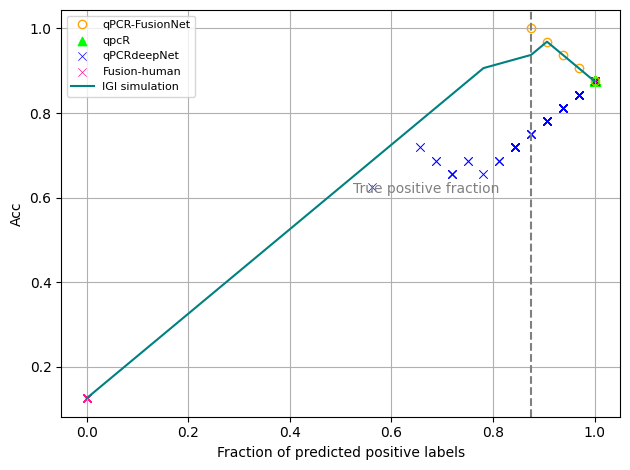

In [ ]:
# plt.plot(chip60_thres_df.pos_pred, 
#          chip60_thres_df.acc, 
#          '.', **{'mfc': 'none', 'mec':'green','mew':0.8}, label='IGI simulation')

# # plt.plot(igi_pos_frac, igi_acc, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.acc, color='blue', label='Model')
# plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.acc, color='orange', marker='x', label='qpcR')



plt.plot(chip60_model_dict_df[['pos_frac','acc']].drop_duplicates().pos_frac, 
         chip60_model_dict_df[['pos_frac','acc']].drop_duplicates().acc, 
         marker='o', fillstyle='none', linestyle='none', 
         color=color_map.get('qPCR-FusionNet'), linewidth=0.0005,
        #  **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
         label='qPCR-FusionNet')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.acc, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(chip60_deepnet_dict_df.pos_frac, chip60_deepnet_dict_df.acc, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidth=0.5,
            # 'x', **{'mfc': 'none', 'mec':color_map.get('qPCRdeepNet'),'mew':0.8},
            label='qPCRdeepNet')
plt.scatter(chip60_humanbased_dict_df.pos_frac, chip60_humanbased_dict_df.acc, 
            color=color_map.get('Fusion-human'), marker='x', linewidth=0.5,
            label='Fusion-human')

plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.acc, 
         color=color_map.get('IGI'), label='IGI simulation')


plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('Acc')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
# plt.title('FPR of different methods when varying thresholds on chip60 set')
plt.tight_layout()
# plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/acc_qpcr_chip60.png')

In [ ]:
chip60_qpcr_dict_df.sort_values('acc', ascending=False).head(1)

,thres,acc,fnr,fpr,pos_frac
0,0.0,0.875,0.0,1.0,1.0


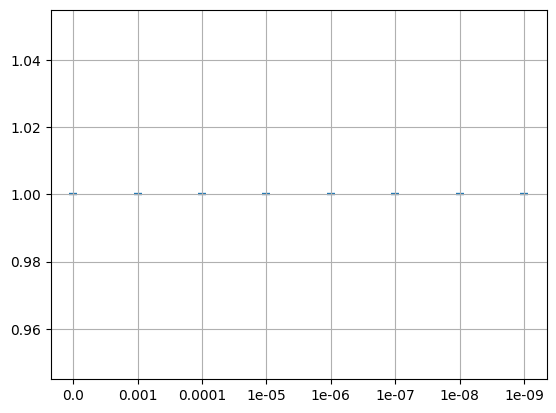

In [ ]:
df = (chip60_qpcr_pred.merge(chip60_deep_pred[['id1','id3']], left_on='curve_idx',right_on='id1'))
plt.scatter(df['id3'].astype('str'), df['prob'], marker='_')
# plt.xscale('log')
plt.grid()

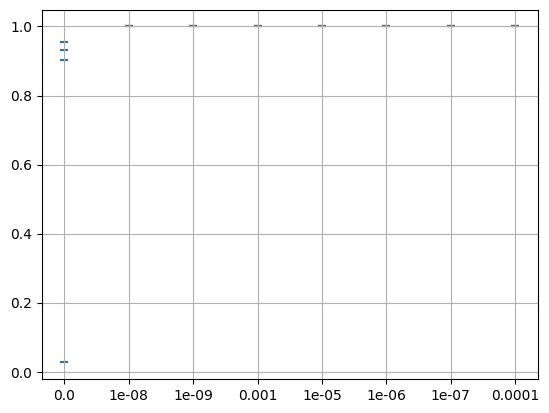

In [ ]:
chip60_pred_full_df.head()

plt.scatter(chip60_pred_full_df.loc[chip60_pred_full_df['Index'] == 1, 'dilution'].astype('str'), chip60_pred_full_df.loc[chip60_pred_full_df['Index'] == 1, 'outputs'], marker='_')
# plt.xscale('log')
plt.grid()

In [ ]:
chip60_thres_df.sort_values('acc', ascending=False)

,perc,cycle,acc,fpr,fnr,pos_pred
120,-0.30,35,0.96875,0.25,0.0,0.90625
135,-0.25,40,0.96875,0.25,0.0,0.90625
147,-0.20,42,0.96875,0.25,0.0,0.90625
146,-0.20,41,0.96875,0.25,0.0,0.90625
145,-0.20,40,0.96875,0.25,0.0,0.90625
...,...,...,...,...,...,...
290,0.55,35,0.12500,0.00,1.0,0.00000
289,0.50,44,0.12500,0.00,1.0,0.00000
288,0.50,43,0.12500,0.00,1.0,0.00000
287,0.50,42,0.12500,0.00,1.0,0.00000


In [ ]:
df = chip60_pred_full_df.copy()
df['new_threshold'] = chip60_pred_full_df.threshold * (1 - 0.3)
        
df['if_pass'] = df.Fn >= df.new_threshold
passed_ids = df[df.if_pass].curve_idx.unique()
df['new_ct'] = np.Inf
df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')

df['new_igi_call'] = 1*(df.new_ct <= 35)
df1 = df[df['Index'] == 1]


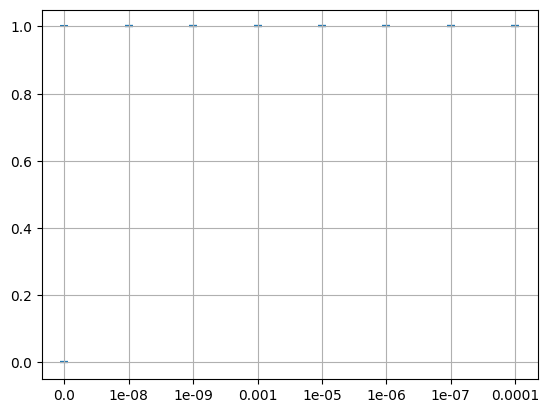

In [ ]:
plt.scatter(df1['dilution'].astype('str'), df1['new_igi_call'], marker='_')
# plt.xscale('log')
plt.grid()

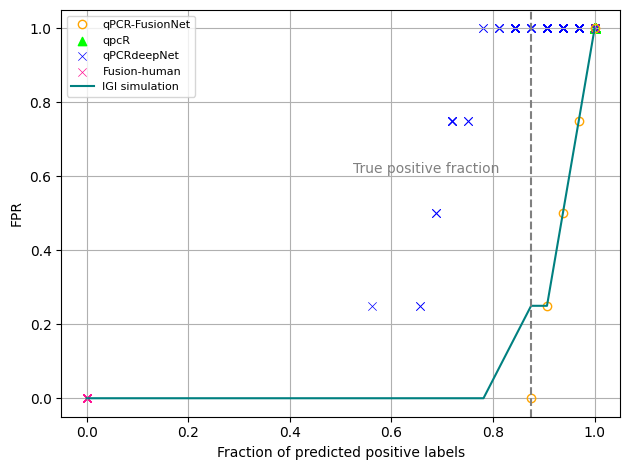

In [ ]:
# plt.plot(chip60_thres_df.pos_pred, 
#          chip60_thres_df.fpr, 
#          '.', **{'mfc': 'none', 'mec':'green','mew':0.8}, label='IGI simulation')

# # plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.fpr, color='blue', label='Model')
# plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fpr, color='orange', marker='x', label='qpcR')



plt.plot(chip60_model_dict_df[['pos_frac','fpr']].drop_duplicates().pos_frac, 
         chip60_model_dict_df[['pos_frac','fpr']].drop_duplicates().fpr, 
         marker='o', fillstyle='none', linestyle='none', 
         color=color_map.get('qPCR-FusionNet'), linewidth=0.0005,
        #  **{'mfc': 'none', 'mec':color_map.get('qPCR-FusionNet'),'mew':0.8},
         label='qPCR-FusionNet')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fpr, 
            color=color_map.get('qpcR'), marker='^', label='qpcR')
plt.scatter(chip60_deepnet_dict_df.pos_frac, chip60_deepnet_dict_df.fpr, 
            color=color_map.get('qPCRdeepNet'), marker='x', linewidth=0.5,
            # 'x', **{'mfc': 'none', 'mec':color_map.get('qPCRdeepNet'),'mew':0.8},
            label='qPCRdeepNet')
plt.scatter(chip60_humanbased_dict_df.pos_frac, chip60_humanbased_dict_df.fpr, 
            color=color_map.get('Fusion-human'), marker='x', linewidth=0.5,
            label='Fusion-human')

plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fpr, 
         color=color_map.get('IGI'), label='IGI simulation')


plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
# plt.title('FPR of different methods when varying thresholds on chip60 set')
plt.tight_layout()
plt.savefig('/home/alpaca/Documents/huong/PCR-huong/PCR_simulation/evaluation/paper_plots/figures/fpr_qpcr_chip60.png')

### IGI Simulation
##### karlen

In [ ]:
# karlen_pred_full = karlen_pred.copy()
# karlen_pred_full = (karlen_df
#                .merge(karlen_pred_full[['curve_idx','outputs']], on='curve_idx'))

In [ ]:
# thermo_df = join_df[(join_df.test_kit == 'Thermo') & (join_df.cycle_no == 37)]
# thermo_threshold_df = thermo_df.groupby('target').threshold.mean()

# thermo_thres_perc_df = pd.DataFrame(thermo_threshold_df)
# thermo_thres_perc_df['percentile'] = np.nan
# for key in thermo_thres_perc_df.index:
#     thermo_thres_perc_df.loc[key,'percentile'] = percentileofscore(thermo_df[thermo_df.target == key].drn, 
#                                                          thermo_threshold_df[key], kind='weak')

# threshold_40 = thermo_thres_perc_df.percentile.mean()

# karlen_threshold = (karlen_pred_full[karlen_pred_full.Cycles == 37]
#                     .groupby('data_set')
#                     .apply(lambda x: scoreatpercentile(x.Fn, threshold_40))
#                     .reset_index(name='threshold'))

# karlen_pred_full = (karlen_pred_full
#              .merge(karlen_threshold, on = 'data_set'))

# karlen_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
# for i in np.arange(0,1,0.001):
#     karlen_pred_full['pred'] = 1*(karlen_pred_full.outputs >= i)
#     tn, fp, fn, tp = confusion_matrix(karlen_pred_full.groundtruth_label, karlen_pred_full.pred, labels=np.array([0,1])).ravel()
    
#     karlen_model_dict['thres'].append(i)
#     karlen_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
#     karlen_model_dict['fnr'].append(fn/(fn+tp))
#     karlen_model_dict['fpr'].append(fp/(fp+tn))
#     karlen_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
# karlen_model_dict_df = pd.DataFrame(karlen_model_dict)
    
# karlen_thres_df = {'perc':[], 'cycle':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

# for perc in np.arange(-.9, 0.9, 0.05):
#     for cycle in range(31, 41):
#         df = karlen_pred_full.copy()
#         df['new_threshold'] = karlen_pred_full.threshold * (1 + perc)
        
#         df['if_pass'] = df.Fn >= df.new_threshold
#         passed_ids = df[df.if_pass].curve_idx.unique()
#         df['new_ct'] = np.Inf
#         df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')
        
#         df['new_igi_call'] = 1*(df.new_ct <= cycle)

#         tn, fp, fn, tp = confusion_matrix(df[df.Cycles == 1].groundtruth_label, df[df.Cycles == 1].new_igi_call, labels=np.array([0,1])).ravel()
        
#         karlen_thres_df['perc'].append(perc)
#         karlen_thres_df['cycle'].append(cycle)
#         karlen_thres_df['fpr'].append(fp/(fp+tn))
#         karlen_thres_df['fnr'].append(fn/(fn+tp))
#         karlen_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))


In [ ]:

# karlen_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
# for i in np.arange(0,1,0.001):
#     karlen_qpcr_pred['pred'] = 1*(karlen_qpcr_pred.prob >= i)
#     tn, fp, fn, tp = confusion_matrix(karlen_qpcr_pred.groundtruth_label, karlen_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
#     karlen_qpcr_dict['thres'].append(i)
#     karlen_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
#     karlen_qpcr_dict['fnr'].append(fn/(fn+tp))
#     karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
#     karlen_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
# karlen_qpcr_dict_df = pd.DataFrame(karlen_qpcr_dict)

In [ ]:
        
# karlen_true_pos_frac = sum(karlen_pred_full.groundtruth_label == 1)/karlen_pred_full.shape[0]
# print('True positive fraction:', karlen_true_pos_frac)
# karlen_thres_df = pd.DataFrame(karlen_thres_df)
# plt.plot(karlen_thres_df.pos_pred, 
#          karlen_thres_df.fnr, 
#          '.', **{'mfc': 'none', 'mec':'green','mew':0.5}, label='IGI simulation')

# plt.plot(karlen_model_dict_df.pos_frac, karlen_model_dict_df.fnr, color='blue', label='Model')
# plt.scatter(karlen_qpcr_dict_df.pos_frac, karlen_qpcr_dict_df.fnr, color='orange', marker='x', label='Model')
# plt.axvline(karlen_true_pos_frac, linestyle='--', color='gray')
# plt.text(x=karlen_true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# # plt.xlim(0.855, 0.885)
# # plt.ylim(0.02,0.05)
# plt.xlabel('Fraction of predicted positive labels')
# plt.ylabel('FNR')
# plt.legend(loc='upper right',fontsize=8)
# plt.grid()
# plt.title('FNR of IGI and model when varying thresholds on karlen set')

#### Chip60

In [ ]:
# chip60_pred_full = chip60_pred.copy()
# chip60_pred_full = (chip60_pred_full
#                     .merge(chip60_df, on='curve_idx'))

In [ ]:
# luner_df = join_df[(join_df.test_kit == 'LuNER') & (join_df.cycle_no == 40)]
# luner_threshold_df = luner_df.groupby('target').threshold.mean()

# luner_thres_perc_df = pd.DataFrame(luner_threshold_df)
# luner_thres_perc_df['percentile'] = np.nan
# for key in luner_thres_perc_df.index:
#     luner_thres_perc_df.loc[key,'percentile'] = percentileofscore(luner_df[luner_df.target == key].drn, 
#                                                          luner_threshold_df[key], kind='weak')

# threshold_45 = luner_thres_perc_df.percentile.mean()

# chip60_threshold = (chip60_pred_full[chip60_pred_full['Index'] == 40]
#                     .groupby('sample')
#                     .apply(lambda x: scoreatpercentile(x.Fn, threshold_45))
#                     .reset_index(name='threshold'))

# chip60_pred_full = (chip60_pred_full
#              .merge(chip60_threshold, on = 'sample'))

# chip60_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
# for i in np.arange(0,1,0.001):
#     chip60_pred_full['pred'] = 1*(chip60_pred_full.outputs >= i)
#     tn, fp, fn, tp = confusion_matrix(chip60_pred_full.groundtruth_label, chip60_pred_full.pred, labels=np.array([0,1])).ravel()
    
#     chip60_model_dict['thres'].append(i)
#     chip60_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
#     chip60_model_dict['fnr'].append(fn/(fn+tp))
#     chip60_model_dict['fpr'].append(fp/(fp+tn))
#     chip60_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
# chip60_model_dict_df = pd.DataFrame(chip60_model_dict)
    

# chip60_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
# for i in np.arange(0,1,0.001):
#     chip60_qpcr_pred['pred'] = 1*(chip60_qpcr_pred.prob >= i)
#     tn, fp, fn, tp = confusion_matrix(chip60_qpcr_pred.groundtruth_label, chip60_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
#     chip60_qpcr_dict['thres'].append(i)
#     chip60_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
#     chip60_qpcr_dict['fnr'].append(fn/(fn+tp))
#     chip60_qpcr_dict['fpr'].append(fp/(fp+tn))
#     chip60_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
# chip60_qpcr_dict_df = pd.DataFrame(chip60_qpcr_dict)
    

# chip60_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

# for perc in np.arange(-.9, 0.9, 0.05):
#     for cycle in range(35, 45):
#         df = chip60_pred_full.copy()
#         df['new_threshold'] = chip60_pred_full.threshold * (1 + perc)
        
#         df['if_pass'] = df.Fn >= df.new_threshold
#         passed_ids = df[df.if_pass].curve_idx.unique()
#         df['new_ct'] = np.Inf
#         df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')
        
#         df['new_igi_call'] = 1*(df.new_ct <= cycle)
#         df_1 = df[df['Index'] == 1]
#         tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
#         chip60_thres_df['fpr'].append(fp/(fp+tn))
#         chip60_thres_df['fnr'].append(fn/(fn+tp))
#         chip60_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
# chip60_true_pos_frac = sum(chip60_pred_full.groundtruth_label == 1)/chip60_pred_full.shape[0]
# print('True positive fraction:', chip60_true_pos_frac)

# chip60_thres_df = pd.DataFrame(chip60_thres_df)
# plt.plot(chip60_thres_df.pos_pred, 
#          chip60_thres_df.fnr, 
#          '.', **{'mfc': 'none', 'mec':'green','mew':0.5}, label='IGI simulation')

# # plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.fnr, color='blue', label='Model')
# plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_model_dict_df.fnr, color='orange', marker='x', label='Model')
# plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
# plt.text(x=chip60_true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# # plt.xlim(0.855, 0.885)
# # plt.ylim(-0.02,0.05)
# plt.xlabel('Fraction of predicted positive labels')
# plt.ylabel('FNR')
# plt.legend(loc='upper right',fontsize=8)
# plt.grid()
# plt.title('FNR of IGI and model when varying thresholds on chip60 set')

### Regression Analysis
#### chip60

In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(chip60_boxplot.loc[chip60_boxplot.model=='qPCR-FusionNet', 'dilution'],
                chip60_boxplot.loc[chip60_boxplot.model=='qPCR-FusionNet', 'predicted_score'])
print(f'Fusion Correlation coef.: {r} - p-value: {p}')

Fusion Correlation coef.: 0.09258182348307332 - p-value: 0.6142825988450241


In [ ]:
# lm_model = sm.OLS()
X = sm.add_constant(chip60_boxplot.loc[chip60_boxplot.model=='qPCR-FusionNet', ['predicted_score']])
model_chip_lm = sm.OLS(chip60_boxplot.loc[chip60_boxplot.model=='qPCR-FusionNet', ['dilution']], X)
results = model_chip_lm.fit()
print('Model chip60 regression')
print(results.summary())

Model chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.024
Method:                 Least Squares   F-statistic:                    0.2594
Date:                Fri, 19 Apr 2024   Prob (F-statistic):              0.614
Time:                        15:54:20   Log-Likelihood:                 211.54
No. Observations:                  32   AIC:                            -419.1
Df Residuals:                      30   BIC:                            -416.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -3

In [ ]:

r, p = pearsonr(chip60_boxplot.loc[chip60_boxplot.model=='qpcR', 'dilution'],
                chip60_boxplot.loc[chip60_boxplot.model=='qpcR', 'predicted_score'])
print(f'Fusion Correlation coef.: {r} - p-value: {p}')

Fusion Correlation coef.: nan - p-value: nan


/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [ ]:

r, p = pearsonr(chip60_boxplot.loc[chip60_boxplot.model=='qPCRdeepNet', 'dilution'],
                chip60_boxplot.loc[chip60_boxplot.model=='qPCRdeepNet', 'predicted_score'])
print(f'Fusion Correlation coef.: {r} - p-value: {p}')

Fusion Correlation coef.: -0.7523970148904493 - p-value: 6.827529202967812e-07


In [ ]:

X = sm.add_constant(chip60_boxplot.loc[chip60_boxplot.model=='qPCRdeepNet', ['predicted_score']])
model_chip_lm = sm.OLS(chip60_boxplot.loc[chip60_boxplot.model=='qPCRdeepNet', ['dilution']], X)
results = model_chip_lm.fit()
print('qPCRdeepNet chip60 regression')
print(results.summary())


qPCRdeepNet chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     39.14
Date:                Fri, 19 Apr 2024   Prob (F-statistic):           6.83e-07
Time:                        16:08:56   Log-Likelihood:                 224.76
No. Observations:                  32   AIC:                            -445.5
Df Residuals:                      30   BIC:                            -442.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       

In [ ]:

X = sm.add_constant(chip60_boxplot.loc[chip60_boxplot.model=='qpcR', ['predicted_score']])
model_chip_lm = sm.OLS(chip60_boxplot.loc[chip60_boxplot.model=='qpcR', ['dilution']], X)
results = model_chip_lm.fit()
print('qpcR chip60 regression')
print(results.summary())


qpcR chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 17 Apr 2024   Prob (F-statistic):                nan
Time:                        10:57:41   Log-Likelihood:                 211.41
No. Observations:                  32   AIC:                            -420.8
Df Residuals:                      31   BIC:                            -419.3
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
predicted_score    

In [ ]:
df = chip60_pred_full_df.copy()

df['if_pass'] = df.Fn >= df.threshold
passed_ids = df[df.if_pass].curve_idx.unique()
df['ct'] = np.Inf
df.loc[df.curve_idx.isin(passed_ids), 'ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')

df['igi_call'] = 1*(df.ct <= cycle)
df_1 = df[df['Index'] == 1]
print(calc_metrics(df_1.groundtruth_label, df_1.igi_call))

X = sm.add_constant(df_1['igi_call'])
model_chip_lm = sm.OLS(df_1['dilution'], X)
results = model_chip_lm.fit()
print('IGI chip60 regression')
print(results.summary())



       acc        f1  tn  fp  fn  tp
0  0.71875  0.808511   4   0   9  19
IGI chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.7551
Date:                Fri, 19 Apr 2024   Prob (F-statistic):              0.392
Time:                        16:06:04   Log-Likelihood:                 211.80
No. Observations:                  32   AIC:                            -419.6
Df Residuals:                      30   BIC:                            -416.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [ ]:

r, p = pearsonr(df_1['dilution'],
                df_1['igi_call'])
print(f'Fusion Correlation coef.: {r} - p-value: {p}')

Fusion Correlation coef.: 0.15668902861029535 - p-value: 0.39177106738808276


#### karlen

In [ ]:

r, p = pearsonr(karlen_boxplot.loc[karlen_boxplot.model=='qPCR-FusionNet', 'inv_dilution_fold'],
                karlen_boxplot.loc[karlen_boxplot.model=='qPCR-FusionNet', 'predicted_score'])
print(f'Fusion Correlation coef.: {r} - p-value: {p}')

Fusion Correlation coef.: 0.11343146103756274 - p-value: 0.061737265820706565


In [ ]:
X = sm.add_constant(karlen_boxplot.loc[karlen_boxplot.model=='qPCR-FusionNet', ['predicted_score']])
model_chip_lm = sm.OLS(karlen_boxplot.loc[karlen_boxplot.model=='qPCR-FusionNet', ['inv_dilution_fold']], X)
results = model_chip_lm.fit()
print('Model karlen regression')
print(results.summary())

Model karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3.519
Date:                Fri, 19 Apr 2024   Prob (F-statistic):             0.0617
Time:                        16:30:25   Log-Likelihood:                -135.56
No. Observations:                 272   AIC:                             275.1
Df Residuals:                     270   BIC:                             282.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             

In [ ]:

r, p = pearsonr(karlen_boxplot.loc[karlen_boxplot.model=='qpcR', 'inv_dilution_fold'],
                karlen_boxplot.loc[karlen_boxplot.model=='qpcR', 'predicted_score'])
print(f'qpcR Correlation coef.: {r} - p-value: {p}')

qpcR Correlation coef.: nan - p-value: nan


/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [ ]:
X = sm.add_constant(karlen_boxplot.loc[karlen_boxplot.model=='qpcR', ['predicted_score']])
model_chip_lm = sm.OLS(karlen_boxplot.loc[karlen_boxplot.model=='qpcR', ['inv_dilution_fold']], X)
results = model_chip_lm.fit()
print('qpcR karlen regression')
print(results.summary())

qpcR karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 19 Apr 2024   Prob (F-statistic):                nan
Time:                        16:31:17   Log-Likelihood:                -137.32
No. Observations:                 272   AIC:                             276.6
Df Residuals:                     271   BIC:                             280.3
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
predicted_score    

In [ ]:
df = karlen_pred_full.copy()

df['if_pass'] = df.Fn >= df.threshold
passed_ids = df[df.if_pass].curve_idx.unique()
df['ct'] = np.Inf
df.loc[df.curve_idx.isin(passed_ids), 'ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')

df['igi_call'] = 1*(df.ct <= cycle)
df_1 = df[df['Cycles'] == 1]
print(calc_metrics(df_1.groundtruth_label, df_1.igi_call))

X = sm.add_constant(df_1['igi_call'])
model_chip_lm = sm.OLS(df_1['inv_dilution_fold'], X)
results = model_chip_lm.fit()
print('IGI karlen regression')
print(results.summary())



        acc      f1  tn  fp   fn   tp
0  0.551471  0.7109   0   0  122  150
IGI karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     14.30
Date:                Fri, 19 Apr 2024   Prob (F-statistic):           0.000191
Time:                        16:31:31   Log-Likelihood:                -130.30
No. Observations:                 272   AIC:                             264.6
Df Residuals:                     270   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:

r, p = pearsonr(df_1['inv_dilution_fold'],
                df_1['igi_call'])
print(f'IGI Correlation coef.: {r} - p-value: {p}')

IGI Correlation coef.: 0.22430993144909128 - p-value: 0.00019146574742234283


In [ ]:

r, p = pearsonr(karlen_boxplot.loc[karlen_boxplot.model=='qPCRdeepNet', 'inv_dilution_fold'],
                karlen_boxplot.loc[karlen_boxplot.model=='qPCRdeepNet', 'predicted_score'])
print(f'qPCRdeepNet Correlation coef.: {r} - p-value: {p}')

qPCRdeepNet Correlation coef.: -0.7169779585877372 - p-value: 3.2947758932321014e-44


In [ ]:
X = sm.add_constant(karlen_boxplot.loc[karlen_boxplot.model=='qPCRdeepNet', ['predicted_score']])
model_chip_lm = sm.OLS(karlen_boxplot.loc[karlen_boxplot.model=='qPCRdeepNet', ['inv_dilution_fold']], X)
results = model_chip_lm.fit()
print('qPCRdeepNet karlen regression')
print(results.summary())

qPCRdeepNet karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     285.6
Date:                Fri, 19 Apr 2024   Prob (F-statistic):           3.29e-44
Time:                        16:33:44   Log-Likelihood:                -39.178
No. Observations:                 272   AIC:                             82.36
Df Residuals:                     270   BIC:                             89.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       

#### known

In [ ]:

r, p = pearsonr(boxplot_df['dilution_level'],
                boxplot_df['outputs'])
print(f'qPCRdeepNet Correlation coef.: {r} - p-value: {p}')

qPCRdeepNet Correlation coef.: 0.1956866567852289 - p-value: 0.003803349537313703


In [ ]:

X = sm.add_constant(boxplot_df[['outputs']])
model_chip_lm = sm.OLS(boxplot_df.dilution_level/boxplot_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('Model known regression')
print(results.summary())

Model known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     8.561
Date:                Fri, 19 Apr 2024   Prob (F-statistic):            0.00380
Time:                        16:36:11   Log-Likelihood:                -71.170
No. Observations:                 217   AIC:                             146.3
Df Residuals:                     215   BIC:                             153.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0204      0.

In [ ]:

r, p = pearsonr(boxplot_df['dilution_level'],boxplot_df['new_igi_call'] )
print(f'IGI Correlation coef.: {r} - p-value: {p}')

IGI Correlation coef.: 0.1917312676869365 - p-value: 0.004591050954135571


In [ ]:
X = sm.add_constant(boxplot_df[['new_igi_call']])
model_chip_lm = sm.OLS(boxplot_df.dilution_level/boxplot_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('IGI known regression')
print(results.summary())

IGI known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     8.205
Date:                Fri, 19 Apr 2024   Prob (F-statistic):            0.00459
Time:                        16:37:17   Log-Likelihood:                -71.343
No. Observations:                 217   AIC:                             146.7
Df Residuals:                     215   BIC:                             153.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         8.056e-06    

In [ ]:

r, p = pearsonr(qpcr_known_pred_df['dilution_level'],
                qpcr_known_pred_df['prob'])
print(f'qpcR Correlation coef.: {r} - p-value: {p}')

qpcR Correlation coef.: 0.21588751572609138 - p-value: 0.0013758488622593427


In [ ]:
X = sm.add_constant(qpcr_known_pred_df[['prob']])
model_chip_lm = sm.OLS(qpcr_known_pred_df.dilution_level/qpcr_known_pred_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('qpcR known regression')
print(results.summary())

qpcR known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     10.51
Date:                Fri, 19 Apr 2024   Prob (F-statistic):            0.00138
Time:                        16:38:26   Log-Likelihood:                -70.228
No. Observations:                 217   AIC:                             144.5
Df Residuals:                     215   BIC:                             151.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1068      0.0

In [ ]:

r, p = pearsonr(known_deep_pred_df['dilution_level'],
                known_deep_pred_df['probability'])
print(f'qPCRdeepNet Correlation coef.: {r} - p-value: {p}')

qPCRdeepNet Correlation coef.: 0.16242292064649946 - p-value: 0.01663200230725657


In [ ]:
X = sm.add_constant(known_deep_pred_df[['probability']])
model_chip_lm = sm.OLS(known_deep_pred_df.dilution_level/known_deep_pred_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('qPCRdeepNet known regression')
print(results.summary())

qPCRdeepNet known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     5.826
Date:                Fri, 19 Apr 2024   Prob (F-statistic):             0.0166
Time:                        16:39:20   Log-Likelihood:                -72.506
No. Observations:                 217   AIC:                             149.0
Df Residuals:                     215   BIC:                             155.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.004

In [ ]:
join_df[join_df.test_kit == 'Thermo'].target.unique()

array(['S gene', 'N gene', 'ORF1ab', 'MS2'], dtype=object)

In [ ]:
join_df[join_df.test_kit == 'LuNER'].target.unique()

array(['RnaseP', 'E gene', 'N gene'], dtype=object)